# Sesgo algorítmico y equidad: medir y corregir decisiones desiguales

> Cómo comprobar si un clasificador trata de forma distinta a grupos definidos por un atributo protegido (sexo, etnia…), qué significa exactamente "equitativo" (independencia, separación, suficiencia), por qué no se pueden cumplir todos los criterios a la vez y qué se puede corregir antes, durante y después del entrenamiento.
>
> **Requisitos previos:** [Flujo de ML y evaluación](01-flujo-ml-y-evaluacion.ipynb) · [Boosting](11-boosting.ipynb) · **Relacionado:** [Muestreo y desbalanceo](../03-preparacion-datos/04-muestreo-y-desbalanceo.ipynb) · [Interpretabilidad](14-interpretabilidad.ipynb)

## 1. Idea clave

Un modelo entrenado con datos históricos aprende también las desigualdades que contienen esos datos, y las **automatiza a escala**: decide quién obtiene un crédito, una entrevista o una libertad condicional. El **sesgo algorítmico** (*algorithmic bias*) aparece cuando los errores o las decisiones del modelo se reparten de forma sistemáticamente distinta entre grupos definidos por un **atributo protegido** (sexo, etnia, edad, discapacidad…).

Se audita **después** de tener un modelo con buena exactitud, porque la exactitud global esconde las diferencias entre grupos. Lo difícil no es calcular las métricas, sino decidir **qué significa ser equitativo**: hay varias definiciones razonables y, salvo casos excepcionales, **no se pueden cumplir a la vez**. Este notebook las define, las mide sobre un caso real (ingresos y sexo en un censo) y prueba tres tipos de corrección, viendo qué cuesta cada una.

## 2. Conceptos importantes

### 2.1. De dónde viene el sesgo

El modelo no "decide discriminar": reproduce lo que hay en los datos y en cómo se plantea el problema. Fuentes típicas:

- **Sesgo histórico**: los datos reflejan una realidad ya desigual (quién ha sido contratado, arrestado o ascendido). Aunque se midan perfectamente, la desigualdad está dentro.
- **Sesgo de representación**: un grupo tiene pocos ejemplos, así que el modelo lo aprende peor y se equivoca más con él.
- **Sesgo de medida o de etiqueta**: la variable objetivo es un sustituto imperfecto de lo que interesa (por ejemplo, "arrestado" en vez de "ha delinquido") y el error de medida no es igual para todos.
- **Variables sustituto** (*proxies*): aunque se elimine el atributo protegido, otras variables lo codifican (código postal, tipo de estudios, estado civil). Es la razón por la que "no mirar el sexo" **no** garantiza que el modelo no lo use (lo veremos en 3.3).
- **Bucles de realimentación**: las decisiones del modelo generan los datos con los que se reentrenará (se patrulla más donde se predijo más delito, se detecta más delito donde se patrulla).

### 2.2. Notación

Sea $Y$ la variable que se quiere predecir, $\hat{Y} = f(X)$ la predicción del modelo y $A$ el atributo protegido. Para simplificar, $A$ es binario (grupo desfavorecido $A=0$ y privilegiado $A=1$) y $Y,\hat{Y}\in\{0,1\}$, donde $1$ es el resultado favorable (conceder, contratar). A partir de la matriz de confusión de **cada grupo** se calculan:

- Tasa de selección: $P(\hat{Y}=1 \mid A=a)$.
- Tasa de verdaderos positivos: $\mathrm{TPR}=P(\hat{Y}=1\mid Y=1, A=a)$ y de falsos positivos: $\mathrm{FPR}=P(\hat{Y}=1\mid Y=0, A=a)$.
- Valor predictivo positivo: $\mathrm{PPV}=P(Y=1\mid \hat{Y}=1, A=a)$.
- Prevalencia o tasa base: $p_a=P(Y=1\mid A=a)$.

### 2.3. Equidad de grupos: tres familias de criterios

Casi todas las definiciones de equidad entre grupos son variantes de tres condiciones de independencia entre $\hat{Y}$, $Y$ y $A$:

| Criterio | Condición | Qué exige en la práctica | Métrica a comparar |
|---|---|---|---|
| **Independencia** (paridad demográfica) | $\hat{Y}\perp A$ | Se acepta la misma proporción de cada grupo | Tasa de selección; ratio de impacto dispar $\dfrac{P(\hat{Y}=1\mid A=0)}{P(\hat{Y}=1\mid A=1)}$ |
| **Separación** (*equalized odds*) | $\hat{Y}\perp A \mid Y$ | Entre quienes merecen el resultado, se acepta igual a todos los grupos; y entre quienes no, se rechaza igual | TPR y FPR |
| **Suficiencia** (calibración por grupos) | $Y\perp A \mid \hat{Y}$ | Una predicción positiva significa lo mismo en todos los grupos | PPV (y NPV) |

Exigir solo la igualdad del TPR se llama **igualdad de oportunidades** (*equal opportunity*) y es una relajación de la separación. La regla de los "cuatro quintos" de la normativa laboral estadounidense considera sospechoso un ratio de impacto dispar inferior a $0{,}8$.

La **independencia** es la más simple, pero ignora la tarea: si las prevalencias $p_a$ son distintas, forzarla obliga a aceptar a más personas no cualificadas de un grupo o a rechazar a más cualificadas del otro. La **separación** respeta esas diferencias reales, pero hereda cualquier sesgo en las etiquetas. La **suficiencia** es lo que quiere quien *usa* la predicción ("un 80 % de riesgo significa lo mismo para cualquiera").

### 2.4. Teoremas de imposibilidad

Salvo casos triviales, **no se pueden cumplir dos criterios a la vez** cuando los grupos tienen prevalencias distintas ($p_0\neq p_1$) y el clasificador no es perfecto. La intuición para suficiencia frente a separación sale de la definición del PPV:

$$
\mathrm{PPV}=\frac{\mathrm{TPR}\,p}{\mathrm{TPR}\,p+\mathrm{FPR}\,(1-p)}
\quad\Longleftrightarrow\quad
\mathrm{FPR}=\frac{p}{1-p}\cdot\frac{1-\mathrm{PPV}}{\mathrm{PPV}}\cdot\mathrm{TPR}.
$$

Si dos grupos tuvieran el mismo PPV y el mismo TPR pero $p$ distinta, sus FPR **tendrían que ser distintos**. Es lo que ocurrió en el caso COMPAS (un sistema que predice reincidencia): una parte lo acusó de sesgo porque los FPR (y por tanto la separación) diferían entre grupos, y la otra lo defendió porque el PPV (la suficiencia) era igual. Ambas tenían razón; usaban criterios distintos. Elegir cuál priorizar no es una decisión técnica sino de contexto, de coste de cada error y de normativa.

Para independencia frente a suficiencia el argumento es parecido: si $A$ y $Y$ no son independientes y se cumple $\hat{Y}\perp A$, no puede cumplirse a la vez $Y\perp A\mid \hat{Y}$.

### 2.5. Otras nociones: equidad individual y causal

- **Equidad individual**: "casos parecidos deben recibir decisiones parecidas". Exige una medida de similitud entre personas, que es justo lo difícil de acordar.
- **Equidad contrafactual**: la decisión no debe cambiar si, manteniendo lo demás igual, cambiáramos solo el atributo protegido. Requiere un modelo causal de los datos, que casi nunca se conoce.

### 2.6. Cómo corregir: antes, durante o después

| Etapa | Idea | Ejemplos |
|---|---|---|
| **Preprocesamiento** | Modificar los datos de entrenamiento | Reponderar observaciones, cambiar etiquetas, descartar variables correlacionadas con $A$ |
| **Durante el aprendizaje** | Cambiar lo que optimiza el modelo | Añadir un término de penalización por discriminación a la función de error, restricciones de equidad, adversario que intenta adivinar $A$ |
| **Posprocesamiento** | Ajustar las salidas de un modelo ya entrenado | Umbrales de decisión distintos por grupo |

La **reponderación** (*reweighing*) da a cada observación el peso

$$
w(a, y) = \frac{P(A=a)\,P(Y=y)}{P(A=a,\,Y=y)},
$$

que es el que haría $A$ e $Y$ independientes en los datos ponderados: sube el peso de las combinaciones menos frecuentes de lo que se esperaría por azar (p. ej., mujeres con ingresos altos) y baja el de las más frecuentes. Probaremos la reponderación y los umbrales por grupo; las correcciones durante el entrenamiento necesitan librerías específicas (Fairlearn, AIF360) que no usa este repositorio.

## 3. Código

Usamos **Adult** (extracción del censo de EE. UU. de 1994, 48 842 personas), cuyo objetivo es predecir si los ingresos anuales superan los 50 000 dólares. Es un conjunto clásico en la literatura de equidad. El atributo protegido será `sex`. La versión de OpenML ya trae las variables categóricas con tipo `category` y los valores ausentes como `NaN` (`workclass`, `occupation`, `native-country`); descartamos `fnlwgt`, el peso muestral del censo, que no describe a la persona. Como los datos son de 1994 y las etiquetas son ingresos *declarados*, los resultados ilustran el método, no la situación actual.

El modelo es `HistGradientBoostingClassifier` ([boosting](11-boosting.ipynb)), que admite directamente variables categóricas y valores ausentes, así que no hace falta preprocesamiento (para otros modelos véase [codificación de variables](../03-preparacion-datos/03-transformacion-datos.ipynb)).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split

### 3.1. Datos, partición y modelo base

Estratificamos la partición por la combinación de clase y sexo para que los cuatro subgrupos estén igual de representados en entrenamiento y test.

In [2]:
adult = fetch_openml("adult", version=2, as_frame=True).frame
y = (adult["class"] == ">50K").astype(int)
X = adult.drop(columns=["class", "fnlwgt"])
print(X.shape)
print("Proporción con ingresos > 50K por sexo:")
print(y.groupby(X["sex"], observed=True).mean().round(3).to_string())
print(X["sex"].value_counts().to_string())

(48842, 13)
Proporción con ingresos > 50K por sexo:
sex
Female    0.109
Male      0.304
sex
Male      32650
Female    16192


In [3]:
estrato = y.astype(str) + X["sex"].astype(str)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=estrato, random_state=42)
y_te = y_test.to_numpy()
sexo_te = X_test["sex"].astype(str).to_numpy()

def nuevo_modelo():
    return HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=42)

modelo = nuevo_modelo().fit(X_train, y_train)
prob_te = modelo.predict_proba(X_test)[:, 1]
pred_base = (prob_te >= 0.5).astype(int)
print(f"Exactitud: {accuracy_score(y_te, pred_base):.3f}   F1: {f1_score(y_te, pred_base):.3f}")

Exactitud: 0.874   F1: 0.712


### 3.2. Auditoría por grupos

Calculamos las métricas de 2.2 por separado en cada grupo. La función `informe_por_grupo` solo necesita las etiquetas reales, las predicciones y el grupo de cada observación.

In [4]:
def informe_por_grupo(y_real, pred, grupo):
    filas = {}
    for g in np.unique(grupo):
        k = grupo == g
        yt, yp = y_real[k], pred[k]
        tp = ((yt == 1) & (yp == 1)).sum(); fp = ((yt == 0) & (yp == 1)).sum()
        fn = ((yt == 1) & (yp == 0)).sum(); tn = ((yt == 0) & (yp == 0)).sum()
        filas[g] = {"n": int(k.sum()), "tasa base": yt.mean(), "tasa de selección": yp.mean(),
                    "TPR": tp / (tp + fn), "FPR": fp / (fp + tn), "PPV": tp / (tp + fp), "exactitud": (tp + tn) / k.sum()}
    return pd.DataFrame(filas).T.astype({"n": int})

informe = informe_por_grupo(y_te, pred_base, sexo_te)
informe.round(3)

,n,tasa base,tasa de selección,TPR,FPR,PPV,exactitud
Female,4858,0.109,0.079,0.584,0.018,0.803,0.939
Male,9795,0.304,0.258,0.664,0.080,0.782,0.842


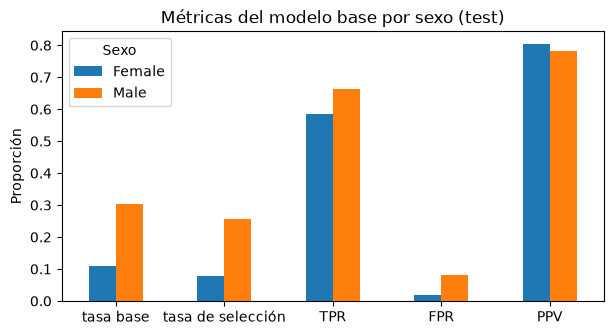

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
informe[["tasa base", "tasa de selección", "TPR", "FPR", "PPV"]].T.plot.bar(ax=ax, rot=0)
ax.set_title("Métricas del modelo base por sexo (test)")
ax.set_ylabel("Proporción")
ax.legend(title="Sexo")
plt.show()

La exactitud es alta en ambos grupos (0,94 para mujeres y 0,84 para hombres), pero casi todo lo demás difiere. La **tasa base** de ingresos altos es 0,11 en mujeres y 0,30 en hombres, y el modelo la amplifica: **selecciona** a un 7,9 % de las mujeres frente a un 25,8 % de los hombres (ratio de impacto dispar $\approx 0{,}31$, muy por debajo de $0{,}8$). El **TPR** es menor en mujeres (0,58 frente a 0,66): a igualdad de ingresos reales altos, el modelo detecta peor a las mujeres. El **FPR** es mucho menor (0,018 frente a 0,080), porque casi nunca da un positivo a una mujer. En cambio el **PPV** es casi igual (0,80 y 0,78): se cumple la suficiencia pero no la independencia ni la separación. Es la situación de COMPAS de 2.4: comprobamos que el FPR que predice la identidad con el PPV y el TPR de cada grupo coincide con el observado.

In [6]:
p = informe["tasa base"]
fpr_identidad = p / (1 - p) * (1 - informe["PPV"]) / informe["PPV"] * informe["TPR"]
pd.DataFrame({"FPR observado": informe["FPR"], "FPR según la identidad": fpr_identidad}).round(3)

,FPR observado,FPR según la identidad
Female,0.018,0.018
Male,0.080,0.080


### 3.3. Quitar el atributo protegido no basta

La primera idea es entrenar sin la columna `sex` ("equidad por desconocimiento", *fairness through unawareness*). Comparamos con el modelo base y comprobamos cuánto de `sex` se puede **reconstruir** a partir de las demás variables.

In [7]:
sin_sexo = nuevo_modelo().fit(X_train.drop(columns="sex"), y_train)
pred_sin = (sin_sexo.predict_proba(X_test.drop(columns="sex"))[:, 1] >= 0.5).astype(int)
print(informe_por_grupo(y_te, pred_sin, sexo_te)[["tasa de selección", "TPR", "FPR", "PPV"]].round(3))

# ¿Se puede adivinar el sexo con el resto de variables?
adivina = nuevo_modelo().fit(X_train.drop(columns="sex"), X_train["sex"] == "Female")
auc = roc_auc_score(X_test["sex"] == "Female", adivina.predict_proba(X_test.drop(columns="sex"))[:, 1])
print(f"\nAUC al predecir el sexo con el resto de variables: {auc:.3f}")
print(pd.crosstab(X["relationship"], X["sex"]).T.to_string())

        tasa de selección    TPR    FPR    PPV
Female              0.078  0.571  0.018  0.795
Male                0.258  0.661  0.082  0.779



AUC al predecir el sexo con el resto de variables: 0.934
relationship  Husband  Not-in-family  Other-relative  Own-child  Unmarried  Wife
sex                                                                             
Female              1           5870             689       3376       3928  2328
Male            19715           6713             817       4205       1197     3


Sin la columna `sex` las métricas apenas cambian (selección de 0,078 y 0,258 frente a 0,079 y 0,258; la diferencia de TPR incluso crece, de $-0{,}080$ a $-0{,}091$): el modelo no la necesitaba. Las demás variables permiten reconstruir el sexo con un AUC de 0,93 (1 sería perfecto, 0,5 azar). Un proxy evidente es `relationship`: casi todos los `Husband` son hombres y casi todas las `Wife` mujeres. **Eliminar el atributo protegido deja intactos sus proxies**, y además impide auditar la equidad, porque ya no se sabe a qué grupo pertenece cada persona. Lo normal es **conservarlo fuera del modelo** para medir, no borrarlo de los datos.

### 3.4. Corrección 1 (antes): reponderar

Calculamos los pesos $w(a,y)$ de 2.6 sobre el entrenamiento y los pasamos como `sample_weight`.

In [8]:
sexo_tr = X_train["sex"].astype(str).to_numpy()
y_tr = y_train.to_numpy()
p_a = pd.Series(sexo_tr).value_counts(normalize=True)
p_y = pd.Series(y_tr).value_counts(normalize=True)
p_ay = pd.crosstab(sexo_tr, y_tr, normalize=True)
pesos = np.array([p_a[a] * p_y[c] / p_ay.loc[a, c] for a, c in zip(sexo_tr, y_tr)])
print(pd.Series(pesos).groupby([sexo_tr, y_tr]).first().round(2).to_string())

repond = nuevo_modelo().fit(X_train, y_train, sample_weight=pesos)
pred_repond = (repond.predict_proba(X_test)[:, 1] >= 0.5).astype(int)

Female  0    0.85
        1    2.19
Male    0    1.09
        1    0.79


### 3.5. Corrección 2 (después): umbrales distintos por grupo

Sin tocar el modelo, cambiamos el umbral de decisión de cada grupo. Los umbrales se eligen con probabilidades **fuera de muestra** del entrenamiento (`cross_val_predict`; mismo principio que en [stacking](12-stacking-y-cascading.ipynb)), nunca con el test. Probamos dos objetivos:

- **Independencia**: que cada grupo tenga la misma tasa de selección que el conjunto (≈ 0,20).
- **Igualdad de oportunidades**: que cada grupo alcance el mismo TPR, el que tenía globalmente el modelo base en entrenamiento.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
prob_oof = cross_val_predict(nuevo_modelo(), X_train, y_train, cv=cv, method="predict_proba")[:, 1]
grupos = np.unique(sexo_tr)

# Independencia: cada grupo selecciona la tasa global del modelo base
tasa_global = (prob_oof >= 0.5).mean()
umbral_ind = {g: np.quantile(prob_oof[sexo_tr == g], 1 - tasa_global) for g in grupos}

# Igualdad de oportunidades: cada grupo alcanza el mismo TPR
tpr_objetivo = ((prob_oof >= 0.5) & (y_tr == 1)).sum() / (y_tr == 1).sum()
umbral_eo = {g: np.quantile(prob_oof[(sexo_tr == g) & (y_tr == 1)], 1 - tpr_objetivo) for g in grupos}

def con_umbrales(prob, grupo, umbrales):
    return np.array([p >= umbrales[g] for p, g in zip(prob, grupo)]).astype(int)

pred_ind = con_umbrales(prob_te, sexo_te, umbral_ind)
pred_eo = con_umbrales(prob_te, sexo_te, umbral_eo)
print(f"Tasa de selección objetivo: {tasa_global:.3f}   TPR objetivo: {tpr_objetivo:.3f}")
print("Umbrales (independencia):", {g: round(u, 3) for g, u in umbral_ind.items()})
print("Umbrales (igualdad de oportunidades):", {g: round(u, 3) for g, u in umbral_eo.items()})

Tasa de selección objetivo: 0.200   TPR objetivo: 0.650
Umbrales (independencia): {'Female': np.float64(0.116), 'Male': np.float64(0.616)}
Umbrales (igualdad de oportunidades): {'Female': np.float64(0.407), 'Male': np.float64(0.512)}


### 3.6. Comparación de las correcciones

Resumimos cada estrategia con la exactitud, el $F_1$ y las diferencias entre mujeres (M) y hombres (H) en cada criterio (en una situación equitativa, el ratio vale 1 y las diferencias valen 0).

In [10]:
def resumen(pred):
    r = informe_por_grupo(y_te, pred, sexo_te)
    m, h = r.loc["Female"], r.loc["Male"]
    return {"exactitud": accuracy_score(y_te, pred), "F1": f1_score(y_te, pred),
            "ratio selección (M/H)": m["tasa de selección"] / h["tasa de selección"],
            "dif. TPR (M-H)": m["TPR"] - h["TPR"], "dif. FPR (M-H)": m["FPR"] - h["FPR"], "dif. PPV (M-H)": m["PPV"] - h["PPV"]}

estrategias = {"Modelo base": pred_base, "Sin la columna sex": pred_sin, "Reponderación": pred_repond,
               "Umbrales: independencia": pred_ind, "Umbrales: igualdad de oportunidades": pred_eo}
pd.DataFrame({nombre: resumen(pred) for nombre, pred in estrategias.items()}).T.round(3)

,exactitud,F1,ratio selección (M/H),dif. TPR (M-H),dif. FPR (M-H),dif. PPV (M-H)
Modelo base,0.874,0.712,0.308,-0.080,-0.063,0.021
Sin la columna sex,0.872,0.708,0.304,-0.091,-0.064,0.016
Reponderación,0.867,0.687,0.587,0.139,0.001,-0.202
Umbrales: independencia,0.848,0.653,1.027,0.288,0.082,-0.400
Umbrales: igualdad de oportunidades,0.873,0.712,0.385,0.005,-0.049,-0.046


- **Sin la columna `sex`** no corrige nada (ratio 0,30, igual que el modelo base).
- **Reponderación** reduce la desigualdad en la selección (ratio 0,59, frente a 0,31), pero se pasa de largo: ahora el TPR es *mayor* en mujeres (diferencia de $+0{,}139$) y el PPV *menor* (diferencia de $-0{,}202$). Tiene un solo mando (los pesos), no un objetivo explícito, y se paga con 0,007 de exactitud.
- **Umbrales por independencia** igualan la selección (ratio 1,03) pero rompen la suficiencia: la diferencia de PPV pasa de $+0{,}021$ a $-0{,}400$. Para llegar a la misma proporción hay que aceptar a mujeres con probabilidad estimada más baja (umbral de 0,12 frente a 0,62 en hombres), y más de ellas resultan no cumplir; también se rompe la separación (diferencias de TPR de $+0{,}288$ y de FPR de $+0{,}082$). Es la imposibilidad de 2.4 en números. Cuesta 0,026 de exactitud.
- **Umbrales por igualdad de oportunidades** igualan el TPR (diferencia de $+0{,}005$), reducen algo la diferencia de FPR (de $-0{,}063$ a $-0{,}049$), mantienen la exactitud (0,873 frente a 0,874) y dejan el PPV parecido (diferencia de $-0{,}046$). Es la opción más barata, pero solo iguala la tasa de detección: la selección sigue siendo muy distinta (ratio 0,39), porque las prevalencias lo son.

Ninguna corrección es "la" correcta: cada una mueve la desigualdad de un criterio a otro. Qué criterio priorizar depende del coste de cada tipo de error en el caso de uso y de lo que exija la normativa.

## 4. Parámetros importantes y errores comunes

### 4.1. Decisiones que hay que tomar

| Decisión | Qué controla | Consejo |
|---|---|---|
| **Atributo protegido $A$** | Qué grupos se comparan | Defínelo con el contexto legal y social; conserva $A$ fuera del modelo para poder auditar |
| **Criterio de equidad** | Qué igualdad se persigue (independencia, separación, suficiencia) | Elígelo según el coste de cada error y quién sufre cada uno; documenta por qué |
| **Umbral de decisión** | Qué porcentaje de cada grupo recibe $\hat{Y}=1$ | Cambiarlo mueve a la vez TPR, FPR y PPV; mira todos |
| **Estrategia de corrección** | Antes, durante o después | Pre: no depende del modelo; durante: mejor equilibrio pero a medida; pos: no hay que reentrenar, pero necesita $A$ al decidir |
| **Datos de calibración** | Con qué datos se eligen pesos o umbrales | Fuera de muestra (validación cruzada), nunca el test |

### 4.2. Errores comunes

- **Mirar solo la exactitud global.** Aquí la exactitud es 0,87 y esconde una selección 3 veces menor para las mujeres. Audita siempre por grupo.
- **Creer que quitar $A$ lo resuelve** (3.3): los proxies siguen ahí y además dejas de poder medir. Revisa qué variables permiten reconstruir $A$.
- **Exigir todos los criterios a la vez.** Con prevalencias distintas es imposible (2.4); elige uno y justifica el motivo. Si alguien presenta "el modelo es equitativo" sin decir según qué criterio, la afirmación no significa nada.
- **Confundir una mejora en un criterio con una mejora global** (3.6): igualar la selección empeoró el PPV de las mujeres de 0,80 a 0,46. Reporta siempre la tabla completa.
- **Ignorar los grupos pequeños y las intersecciones.** Auditar por `sex` y por `race` por separado puede esconder lo que pasa en `sex × race`. La demo siguiente muestra lo poco fiables que son las métricas cuando un subgrupo tiene pocos positivos.
- **Tomar las etiquetas como verdad.** La separación y la suficiencia se calculan con $Y$: si $Y$ ya está sesgado (quién ha sido contratado, arrestado), el modelo puede ser "equitativo" respecto a una realidad injusta.
- **Corregir sobre el test.** Elegir los umbrales con el test infla el resultado, igual que cualquier ajuste de hiperparámetros ([flujo de ML](01-flujo-ml-y-evaluacion.ipynb)).

#### Demo: métricas por intersección de grupos

In [11]:
raza_te = X_test["race"].astype(str).to_numpy()
inter = pd.Series(sexo_te) + " / " + pd.Series(raza_te)
res = []
for g in np.unique(inter):
    k = (inter == g).to_numpy()
    positivos = int(y_te[k].sum())
    tpr = ((pred_base[k] == 1) & (y_te[k] == 1)).sum() / positivos if positivos else np.nan
    res.append({"grupo": g, "n": int(k.sum()), "positivos reales": positivos, "TPR": tpr})
pd.DataFrame(res).set_index("grupo").sort_values("n").round(2)

,n,positivos reales,TPR
grupo,,,
Female / Other,46,3,0.67
Female / Amer-Indian-Eskimo,62,3,0.67
Male / Other,73,11,0.55
Male / Amer-Indian-Eskimo,88,9,0.56
Female / Asian-Pac-Islander,152,24,0.46
Male / Asian-Pac-Islander,281,81,0.74
Female / Black,649,41,0.46
Male / Black,670,130,0.62
Female / White,3949,460,0.60


Los cuatro subgrupos más pequeños tienen entre 46 y 88 personas y solo entre 3 y 11 positivos reales: un TPR de 0,67 calculado con 3 positivos (2 aciertos) no dice nada, y el de mujeres asiáticas (0,46, con 24 positivos) tampoco permite concluir frente a 0,74 en hombres sin medir la incertidumbre. Antes de afirmar que un grupo está peor tratado hay que comprobar que hay datos suficientes (por ejemplo, con un intervalo por *bootstrap*).

## 5. Comparación con métodos relacionados

Las tres familias de corrección, evaluadas en 3.6:

| Etapa | Qué toca | Necesita $A$ al predecir | Ventaja | Inconveniente | Cuándo usarlo |
|---|---|---|---|---|---|
| **Preprocesamiento** (reponderación) | Datos de entrenamiento | No | Sirve para cualquier modelo posterior | Poco control sobre el resultado final (en 3.4, se pasó de largo) | Cuando el sesgo está claramente en los datos y no puedes tocar el modelo |
| **Durante el aprendizaje** (restricciones, penalización, adversario) | Función de error | No siempre | Mejor equilibrio entre error y equidad, porque se optimiza a la vez | Requiere librerías y modelos específicos | Cuando controlas el entrenamiento y la equidad es un requisito de diseño |
| **Posprocesamiento** (umbrales por grupo) | Salidas del modelo | **Sí** | No hay que reentrenar; funciona con modelos ajenos | Necesita $A$ en producción (a veces ilegal) y puede perder exactitud | Cuando solo tienes el modelo o sus probabilidades |

La interpretabilidad ([notebook 14](14-interpretabilidad.ipynb)) es complementaria: sirve para ver **qué variables** mueven la decisión (por ejemplo, si el atributo protegido o sus proxies pesan mucho), mientras que las métricas de este notebook dicen **si** el resultado es desigual.

## 6. Referencias

### Fuentes

- Becker, B. y Kohavi, R. (1996). [*Adult*](https://archive.ics.uci.edu/dataset/2/adult). UCI Machine Learning Repository. Versión descargada con [`fetch_openml("adult", version=2)`](https://www.openml.org/search?type=data&id=1590) de OpenML.
- scikit-learn: [`fetch_openml`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html), [`HistGradientBoostingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html) (variables categóricas, `sample_weight`), [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), [métricas de clasificación](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics).
- pandas: [documentación](https://pandas.pydata.org/docs/) (`crosstab`, `groupby`).

### Para saber más

- Barocas, S., Hardt, M. y Narayanan, A. (2023). [*Fairness and Machine Learning: Limitations and Opportunities*](https://fairmlbook.org). MIT Press. El libro de referencia: define independencia, separación y suficiencia y demuestra los resultados de imposibilidad.
- Chouldechova, A. (2017). [«Fair prediction with disparate impact: A study of bias in recidivism prediction instruments»](https://doi.org/10.1089/big.2016.0047). *Big Data*, 5(2), 153–163. Análisis del caso COMPAS y origen de la identidad entre PPV, TPR y FPR de 2.4.